In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data.csv')

In [3]:
categorical = [
    'lead_source',
    'industry',
    'employment_status',
    'location'
]
full_numerical = [
    'annual_income', 
    'number_of_courses_viewed', 
    'interaction_count',
    'lead_score',
    'converted'
]

numerical = [
    'annual_income', 
    'number_of_courses_viewed', 
    'interaction_count',
    'lead_score',
    # 'converted'
]

for c in categorical:
    df[c] = df[c].fillna('NA')

for n in full_numerical:
    df[n] = df[n].fillna(0.0)

df.isnull().sum()

lead_source                 0
industry                    0
employment_status           0
location                    0
annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [4]:
from sklearn.model_selection import train_test_split


df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=1
)

y_full_train = df_full_train.converted
y_train = df_train.converted
y_val = df_val.converted
y_test = df_test.converted

del df_full_train['converted']
del df_train['converted']
del df_val['converted']
del df_test['converted']



In [5]:
# Q1: lead_score
from sklearn.metrics import roc_auc_score


for n in numerical:
    auc = roc_auc_score(y_train, df_train[n])
    print(f"{n}: {auc}")

annual_income: 0.6081977776250831
number_of_courses_viewed: 0.7229894623989618
interaction_count: 0.7649203047563227
lead_score: 0.7882254810906102


In [6]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [7]:
# Q2: 0.732
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict_proba(X_val)[:, 1]

roc_auc_score(y_val, y_pred)

0.7318222288173319

/var/folders/xy/v_c2s91s1nj61nckv2hjx75r0000gn/T/ipykernel_16558/191724564.py:19: RuntimeWarning: invalid value encountered in scalar divide
  p = tp / (tp + fp)


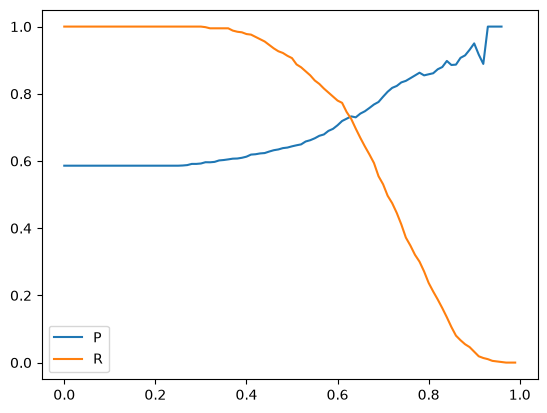

In [8]:
# Q3: 0.63
thresholds = np.arange(0, 1, 0.01)
scores = []

actual_positive = (y_val == 1)
actual_negative = (y_val == 0)


for t in thresholds:
    predict_positive = (y_pred >= t)
    predict_negative = (y_pred < t)

    tp = (predict_positive & actual_positive).sum()
    tn = (predict_negative & actual_negative).sum()

    fp = (predict_positive & actual_negative).sum()
    fn = (predict_negative & actual_positive).sum()

    p = tp / (tp + fp)
    r = tp / (tp + fn)

    scores.append((t, p, r))

columns = ['threshold', 'p', 'r']
df_scores = pd.DataFrame(scores, columns=columns)

plt.plot(df_scores.threshold, df_scores['p'], label='P')
plt.plot(df_scores.threshold, df_scores['r'], label='R')
plt.legend()

In [9]:
def f1(p, r):
    return 2 * ((p * r) / (p + r))

In [10]:
# Q4: 0.41
df_scores['f1'] = f1(df_scores['p'], df_scores['r'])
df_scores.sort_values('f1', ascending=False)

,threshold,p,r,f1
41,0.41,0.619048,0.976109,0.757616
42,0.42,0.620087,0.969283,0.756325
43,0.43,0.622517,0.962457,0.756032
45,0.45,0.628118,0.945392,0.754768
44,0.44,0.623608,0.955631,0.754717
...,...,...,...,...
95,0.95,1.000000,0.003413,0.006803
96,0.96,1.000000,0.001706,0.003407
97,0.97,NaN,0.000000,NaN
98,0.98,NaN,0.000000,NaN


In [11]:
from sklearn.model_selection import KFold

In [12]:
# Q5: 0.007
# Q6: 0.001

kfold = KFold(n_splits=5, shuffle=True, random_state=1)

C = [0.000001, 0.001, 1]

for c in C:

    auc_scores = []

    df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        # train
        dicts = df_train[categorical + numerical].to_dict(orient='records')

        dv = DictVectorizer(sparse=False)
        X_train = dv.fit_transform(dicts)

        model = LogisticRegression(solver='liblinear', C=c, max_iter=1000)
        model.fit(X_train, y_train)

        # predict
        dicts = df_val[categorical + numerical].to_dict(orient='records')

        X = dv.transform(dicts)
        y_pred = model.predict_proba(X)[:, 1]

        # auc score
        auc = roc_auc_score(y_val, y_pred)
        auc_scores.append(auc)

    
    print(f"C: {c} -- STD: {np.std(auc_scores)} -- Mean ROC AUC: {np.mean(auc_scores)}")

C: 1e-06 -- STD: 0.018669799234831475 -- Mean ROC AUC: 0.6167342250714795
C: 0.001 -- STD: 0.009996375455700753 -- Mean ROC AUC: 0.7491721776030379
C: 1 -- STD: 0.006853233151022138 -- Mean ROC AUC: 0.7317269710972524
